In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from scipy.stats import mannwhitneyu
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import sys
from tqdm import tqdm
sys.path.append("../src")
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
from border_effects_kNN_del import trunc_graphs, get_mibitof, get_squidpy_visium_datasets

In [4]:
np.random.seed(41)

In [10]:
COORDS_PICKLE_PATH = "/data/bionets/je30bery/truncated_graphs/mibitof_coords/coords.pickle"
DELAUNAY_EDGE_STATISTICS_PATH = "/data/bionets/je30bery/truncated_graphs/results/figure1/del_trunc.csv"
KNN_EDGE_STATISTICS_PATH = "/data/bionets/je30bery/truncated_graphs/results/figure1/kNN_trunc.csv"

In [8]:
try:
    with open(COORDS_PICKLE_PATH, "rb") as f:
        datasets = pickle.load(f)
except FileNotFoundError:
    datasets = get_mibitof().update(get_squidpy_visium_datasets())
    with open(COORDS_PICKLE_PATH, "wb") as f:
        pickle.dump(datasets, f)

In [9]:
try:
    all_results_del = pd.read_csv(DELAUNAY_EDGE_STATISTICS_PATH)
except:
    dfs = list()
    for square_limits in [(1/8, 7/8)]:
        df = pd.DataFrame(columns=["data_source", "node density in ROI", "% new edges", "P", "border_size"])
        for dataset in tqdm(datasets):
            coords = datasets[dataset]
            width = np.max(coords[:, 0]) - np.min(coords[:, 0])
            height = np.max(coords[:, 1]) - np.min(coords[:, 1])
            assert width > 0 and height > 0, f"problem, {width}, {height}"
                        
            xlim = (np.min(coords[:, 0]) + width * square_limits[0], np.min(coords[:, 0]) + width * square_limits[1])
            ylim = (np.min(coords[:, 1]) + height * square_limits[0], np.min(coords[:, 1]) + height * square_limits[1]) 
    
            try:
                out = trunc_graphs(coords=coords, return_graphs=False, method="delaunay", xlim=xlim, ylim=ylim)
                edge_df = out["edge_df"]
            
                old = edge_df.loc[~edge_df["New edge"], "Edge length"]
                new = edge_df.loc[edge_df["New edge"], "Edge length"]
            
                p_mwu = mannwhitneyu(
                    old,
                    new,
                    alternative="two-sided"
                ).pvalue
                data_source = dataset.split(":")[0]
                df.loc[dataset] = [data_source, out["#nodes in ROI"] / (float(height) * float(width)), len(new) / (len(new) + len(old)), p_mwu, square_limits[0]]
            except: # if too few cells are within ROI
                continue
        dfs.append(df)
    
    all_results_del = pd.concat(dfs)
    all_results_del["% new edges"] *= 100
    _, all_results_del["P_adj"], _, _ = multipletests(all_results_del["P"], alpha=0.05, method="fdr_bh")
    all_results_del.to_csv(DELAUNAY_EDGE_STATISTICS_PATH)

In [11]:
try:
    all_results_knn = pd.read_csv(KNN_EDGE_STATISTICS_PATH)
except:
    dfs = list()
    ks = [5, 10, 15]
    for square_limits in [(1/8, 7/8)]:
        for k in ks:
            df = pd.DataFrame(columns=["data_source", "#nodes in ROI", "node density in ROI", "% new edges", "P_MWU", "P_fisher", "border_size", "k", "img_size"])
            for dataset in tqdm(datasets):
                coords = datasets[dataset]
                width = np.max(coords[:, 0]) - np.min(coords[:, 0])
                height = np.max(coords[:, 1]) - np.min(coords[:, 1])
                assert width > 0 and height > 0, f"problem, {width}, {height}"
                    
                
                xlim = (np.min(coords[:, 0]) + width * square_limits[0], np.min(coords[:, 0]) + width * square_limits[1])
                ylim = (np.min(coords[:, 1]) + height * square_limits[0], np.min(coords[:, 1]) + height * square_limits[1]) 
        
                try:
                    out = trunc_graphs(coords=coords, return_graphs=False, method="kNN", xlim=xlim, ylim=ylim, k=k)
                    edge_df = out["edge_df"]
                
                    old = edge_df.loc[~edge_df["New edge"], "Edge length"]
                    new = edge_df.loc[edge_df["New edge"], "Edge length"]
                
                    p_mwu = mannwhitneyu(
                        old,
                        new,
                        alternative="two-sided"
                    ).pvalue
    
                    contingency = pd.crosstab(edge_df["New edge"], edge_df["Symmetry"])
                    values = np.array([[contingency.loc[True, False], contingency.loc[True, True]],
                                              [contingency.loc[False, False], contingency.loc[False, True]]])
                    _, p_fisher = fisher_exact(values, alternative="greater")
    
                    data_source = dataset.split(":")[0]
                    df.loc[dataset] = [data_source, out["#nodes in ROI"], out["#nodes in ROI"] / (float(height) * float(width)), len(new) / (len(new) + len(old)), p_mwu, p_fisher, square_limits[0], k, (height, width)]
                except: # if too few cells are within ROI
                    continue
            dfs.append(df)
    all_results_knn = pd.concat(dfs)
    all_results_knn["% new edges"] *= 100
    _, all_results_knn["P_MWU_adj"], _, _ = multipletests(all_results_knn["P_MWU"], alpha=0.05, method="fdr_bh")
    _, all_results_knn["P_fisher_adj"], _, _ = multipletests(all_results_knn["P_fisher"], alpha=0.05, method="fdr_bh")
    all_results_knn.to_csv(KNN_EDGE_STATISTICS_PATH)

In [12]:
square_limits = (1/8, 7/8)
coords = datasets['glioma_mibitof:Brainiaqc_R1C1_whole_cell.tiff']
width = np.max(coords[:, 0]) - np.min(coords[:, 0])
height = np.max(coords[:, 1]) - np.min(coords[:, 1])

xlim = (np.min(coords[:, 0]) + width * square_limits[0], np.min(coords[:, 0]) + width * square_limits[1])
ylim = (np.min(coords[:, 1]) + height * square_limits[0], np.min(coords[:, 1]) + height * square_limits[1]) 

out = trunc_graphs(coords=coords, return_graphs=True, method="delaunay", xlim=xlim, ylim=ylim)

coords = out["coords"]
subset = out["subset"]

G = out["G"]
subG = out["subG"]
plotG = out["plotG"]
truncG = out["truncG"]

edge_df = out["edge_df"]

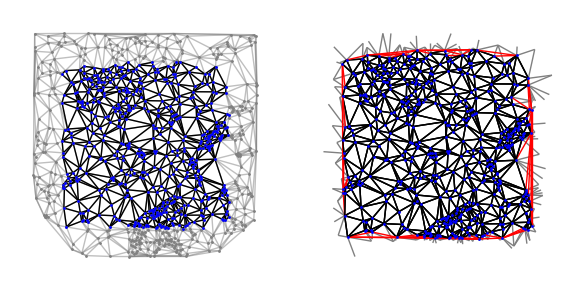

In [15]:
f, axs = plt.subplots(1, 2, figsize=(6, 3))

nx.draw(G, pos=coords, edge_color=(0.5, 0.5, 0.5, 0.5), node_size=1, node_color="gray", ax=axs[0])
nx.draw(subG, node_size=1, pos=coords, node_color="blue", ax=axs[0])

nx.draw_networkx_edges(plotG, pos=coords, ax=axs[1], edge_color="gray")
nx.draw(subG, node_size=1, pos=coords, ax=axs[1], node_color="blue")

edge_colors = [edge in G.edges for edge in truncG.edges]
nx.draw_networkx_edges(truncG, pos=coords, ax=axs[1], edge_color=np.where(edge_colors, "black", "red")) #, node_color=subcoords[:, 2], cmap="magma", vmin=-1, vmax=1)

for ax in axs:
    ax.set_aspect('equal')

plt.tight_layout()
#plt.savefig("../result_plots/fig2/delaunay_trunc_1.svg")

<Axes: ylabel='Edge length'>

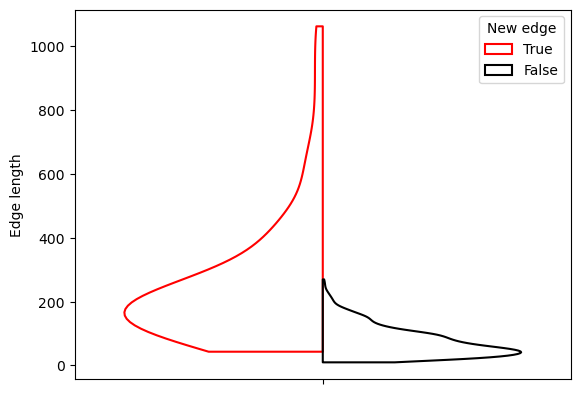

In [16]:
sns.violinplot(edge_df, y="Edge length", hue="New edge", cut=0, fill=False, split=True, palette={False: "black", True: "red"}, hue_order=[True, False], inner=None)

In [18]:
sources = sorted(list(all_results_del["data_source"].unique()))
palette = dict(zip(sources, sns.color_palette("magma", len(sources))))

/tmp/ipykernel_3805084/4130369893.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:green'` for the same effect.

  sns.violinplot(all_results_knn, hue="k", y="% new edges", ax=axs[2], legend=False, fill=False, color="green")
/tmp/ipykernel_3805084/4130369893.py:7: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:green'` for the same effect.

  sns.violinplot(all_results_knn, hue="k", y="P_MWU_adj", ax=axs[3], legend=False, fill=False, color="green")
/tmp/ipykernel_3805084/4130369893.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:green'` for the same effect.

  sns.violinplot(all_results_knn, hue="k", y="P_fisher_adj", ax=axs[4], legend=True, fill=False, color="green")


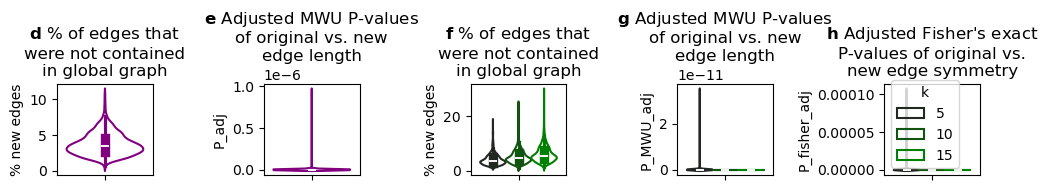

In [35]:
f, axs = plt.subplots(1, 5, figsize=(10, 2))

sns.violinplot(all_results_del, y="% new edges", ax=axs[0], legend=False, fill=False, color="purple")
sns.violinplot(all_results_del, y="P_adj", ax=axs[1], legend=False, fill=False, color="purple")

sns.violinplot(all_results_knn, hue="k", y="% new edges", ax=axs[2], legend=False, fill=False, color="green")
sns.violinplot(all_results_knn, hue="k", y="P_MWU_adj", ax=axs[3], legend=False, fill=False, color="green")
sns.violinplot(all_results_knn, hue="k", y="P_fisher_adj", ax=axs[4], legend=True, fill=False, color="green")

axs[0].set_title("$\\mathbf{d}$ % of edges that\nwere not contained\nin global graph")
axs[1].set_title("$\\mathbf{e}$ Adjusted MWU P-values\nof original vs. new\nedge length")
axs[2].set_title("$\\mathbf{f}$ % of edges that\nwere not contained\nin global graph")
axs[3].set_title("$\\mathbf{g}$ Adjusted MWU P-values\nof original vs. new\nedge length")
axs[4].set_title("$\\mathbf{h}$ Adjusted Fisher's exact\nP-values of original vs.\nnew edge symmetry")

#for i in [1, 3, 4]:
#    axs[i].set_yscale("log")

plt.tight_layout()
plt.savefig("../result_plots/delaunay_trunc.svg", bbox_inches="tight")

In [37]:
all_results_del["% new edges"].median()

3.4703683929524822

In [40]:
for k, sub_df in all_results_knn.groupby("k"):
    print(k, sub_df["% new edges"].max(), sub_df["% new edges"].median())

5 18.02469135802469 3.546099290780142
10 24.320987654320987 4.477317554240631
15 28.85057471264368 5.319987867758568
